# 04 - Full temporal fine-tuning with SVD_Xtend

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/matu1003/Makeitalive/blob/main/notebooks/04_svd_xtend.ipynb)

The LoRA runs of [`03_svd_lora`](03_svd_lora.ipynb) only produced slight parallax, so we fine-tuned the temporal
layers of SVD directly, using the training code of [SVD_Xtend](https://github.com/pixeli99/SVD_Xtend)
(spatial layers frozen, `lr=1e-5`, 5000 steps at 320x320, bf16). **This is the run behind our final results.**

The dataset is the one extracted in `03_svd_lora.ipynb` with `frame_gap=12` and `interval=7.0`: 2,374
motion-filtered clips of 14 frames. This notebook was run on Colab with an A100 GPU and Google Drive for
persistence. The training log has been cleared, but the comparison videos generated by the run are kept below.

> Runtime > Change runtime type > A100 GPU

In [ ]:
# 1. Check GPU
!nvidia-smi

Tue Mar 31 17:44:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   35C    P0             48W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# Install dependencies. On Colab, clone this repo and install it with the svd extra;
# locally, `uv sync --extra svd` is enough.
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !git clone -q https://github.com/matu1003/Makeitalive.git
    %cd Makeitalive
    !pip install -q -e ".[svd]"
    REPO_ROOT = Path.cwd()
else:
    REPO_ROOT = Path.cwd().parent

## 1. Data

The clips live on Drive, but they are copied to the local runtime first: reading thousands of JPEGs
directly from Drive is far too slow during training.

In [ ]:
# 3. (Optional) Mount Google Drive to persist data/checkpoints
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Change these if you want to save elsewhere
DATA_DIR   = '/content/drive/MyDrive/svd_landscape/data_v3'
CKPT_DIR   = '/content/drive/MyDrive/svd_landscape/checkpoints4'

Mounted at /content/drive


In [ ]:
# Copy the dataset from Drive to the local runtime (faster I/O during training)
!cp -r '/content/drive/MyDrive/svd_landscape/data_v3' '/content/data_v3'

^C


In [ ]:
# Check
!ls /content/data_v3 | head -5
!ls /content/data_v3 | wc -l

ls: cannot access '/content/data_v3': No such file or directory
ls: cannot access '/content/data_v3': No such file or directory
0


Total clips: 2374


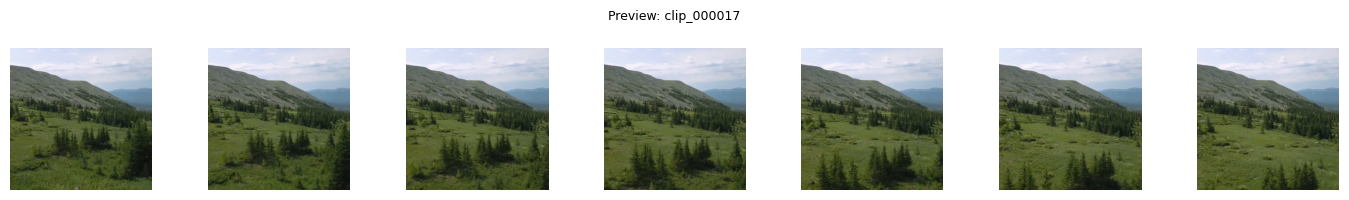

In [ ]:
# 6. Verify dataset
import os
clips = [d for d in os.listdir(DATA_DIR) if d.startswith('clip_')]
print(f'Total clips: {len(clips)}')

# Preview first clip
from PIL import Image
import matplotlib.pyplot as plt

first_clip = sorted(clips)[17]
frames = sorted(os.listdir(os.path.join(DATA_DIR, first_clip)))
fig, axes = plt.subplots(1, min(7, len(frames)), figsize=(14, 2))
for ax, fname in zip(axes, frames[:7]):
    ax.imshow(Image.open(os.path.join(DATA_DIR, first_clip, fname)))
    ax.axis('off')
plt.suptitle(f'Preview: {first_clip}', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Hugging Face login

Needed to download the pretrained SVD weights.

In [ ]:
# 7. Login to HuggingFace (needed to download SVD weights)
# Get your token at https://huggingface.co/settings/tokens
from huggingface_hub import login
login()  # prompts for your token

## 3. Get SVD_Xtend and patch it

Two fixes are applied to `train_svd.py`:

1. **autocast with bf16**: the original code only enables autocast for `fp16`, which breaks mixed-precision
   training on an A100 with `bf16`.
2. **checkpoint saving**: the model is saved through `accelerator.unwrap_model(...)`, otherwise the saved
   UNet weights are empty (a few hundred bytes instead of ~3 GB).

In [ ]:
!git clone https://github.com/pixeli99/SVD_Xtend.git
!cd SVD_Xtend

Cloning into 'SVD_Xtend'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 121 (delta 37), reused 25 (delta 25), pack-reused 75 (from 1)
Receiving objects: 100% (121/121), 487.50 KiB | 3.87 MiB/s, done.
Resolving deltas: 100% (55/55), done.


In [ ]:
from svd_xtend.patch import apply_patches

apply_patches("/content/SVD_Xtend")

## 4. Training

5000 steps at 320x320, `lr=1e-5`, batch size 5, bf16, 14 frames per clip, on an A100,
with a checkpoint every 1000 steps.

In [ ]:
!cd SVD_Xtend && accelerate launch train_svd.py \
    --per_gpu_batch_size=5 \
    --pretrained_model_name_or_path stabilityai/stable-video-diffusion-img2vid \
    --max_train_steps=5000 \
    --width=320 \
    --height=320 \
    --learning_rate=1e-5 \
    --mixed_precision="bf16" \
    --checkpointing_steps=1000 \
    --seed=42 \
    --num_frames=14 \
    --output_dir '/content/drive/MyDrive/svd_landscape/checkpoints_xtend' \
    --base_folder '/content/drive/MyDrive/svd_landscape/data_v3' \
    --checkpoints_total_limit=10

## 5. Checkpoints

Sanity check: each `unet/diffusion_pytorch_model.safetensors` must weigh ~3 GB. This is what the saving patch fixes.

In [ ]:
import os

base = '/content/drive/MyDrive/svd_landscape/checkpoints_xtend'

# Check all checkpoints AND the root
for folder in [f'checkpoint-{s}' for s in range(1000, 5001, 1000)]:
    unet_dir = os.path.join(base, folder, 'unet')
    print(f"\n{folder}/unet:")
    if os.path.exists(unet_dir):
        for f in os.listdir(unet_dir):
            size = os.path.getsize(os.path.join(unet_dir, f))
            print(f"  {f}    {size:,} bytes")
    else:
        print("  [directory does not exist]")

# Also check the root unet dir (the final save)
root_unet = os.path.join(base, 'unet')
print(f"\ncheckpoints_xtend/unet/ (final save):")
if os.path.exists(root_unet):
    for f in os.listdir(root_unet):
        size = os.path.getsize(os.path.join(root_unet, f))
        print(f"  {f}    {size:,} bytes ({size/1e9:.2f} GB)")

# Check optimizer.bin  it actually contains model state in some accelerate versions
opt = os.path.join(base, 'checkpoint-3000', 'optimizer.bin')
if os.path.exists(opt):
    size = os.path.getsize(opt)
    print(f"\noptimizer.bin: {size:,} bytes ({size/1e9:.2f} GB)")

## 6. Rollout: input, generated, ground truth

For each clip, the last checkpoint animates its first frame, and the result is assembled into a single
comparison video: the still input, the raw generation (7 fps), the real clip, then the generation slowed to
2 fps and interpolated to 24 fps with `ffmpeg minterpolate`. Each segment is labelled with `drawtext`.

In [ ]:
from svd_xtend.rollout import rollout

videos = rollout(
    checkpoint_dir='/content/drive/MyDrive/svd_landscape/checkpoints_xtend',
    clips_dir=DATA_DIR,
    out_dir='/content/output_videos',
    num_clips=5,          # raise this for a full run
    motion_bucket_id=127,
)

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
from IPython.display import display, Video
import os

output_dir = '/content/output_videos'
videos = sorted([f for f in os.listdir(output_dir) if f.endswith('.mp4')])

print(f"{len(videos)} videos generated:\n")
for v in videos:
    path = os.path.join(output_dir, v)
    print(f"> {v}")
    display(Video(path, embed=True, width=900))

5 vidéos générées :

▶ compare_all00.mp4


▶ compare_all01.mp4


▶ compare_all02.mp4


▶ compare_all03.mp4


▶ compare_all04.mp4


## 7. Results

The clips below are the ones produced by this notebook (`INPUT` then `GENERATED + INTERP`), compared with
the pretrained model:

| Pretrained SVD | SVD_Xtend fine-tuned |
|:---:|:---:|
| <img src="../assets/gifs/svd_not_trained.gif" width="320"> | <img src="../assets/gifs/svd_final_2.gif" width="320"> |

The fine-tuned model produces drone-like camera motion with parallax, and generates the parts of the scene
revealed by the movement. See the [report](../docs/report.pdf) for the comparison with LoRA.